In [6]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)


In [7]:
# Cell 2: Load preprocessed dataset (v2 with new features)
df = pd.read_csv("../Data/final_classification_ready_v2.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (45155, 18)
Columns: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'HourlyDewPointTemperature', 'HourlyDryBulbTemperature', 'HourlyRelativeHumidity', 'HourlyVisibility', 'HourlyWindSpeed', 'DEP_DEL15', 'OP_UNIQUE_CARRIER_ENC', 'ORIGIN_ENC', 'DEST_ENC', 'TIME_OF_DAY_ENC', 'TEMP_DIFF']


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,DEP_DEL15,OP_UNIQUE_CARRIER_ENC,ORIGIN_ENC,DEST_ENC,TIME_OF_DAY_ENC,TEMP_DIFF
0,4,1,2,6.53,9.33,168.0,1020.0,33.0,36.0,89.0,5.0,10.0,0.0,0,1,62,2,3.0
1,4,1,2,15.45,18.12,160.0,1020.0,33.0,45.0,63.0,10.0,10.0,1.0,0,1,62,0,12.0
2,4,1,2,7.33,15.32,299.0,2279.0,37.0,43.0,80.0,10.0,6.0,0.0,0,4,14,2,6.0
3,4,1,2,13.83,21.83,300.0,2279.0,41.0,49.0,74.0,10.0,6.0,0.0,0,4,14,1,8.0
4,4,1,2,22.00,6.00,300.0,2279.0,41.0,45.0,86.0,10.0,7.0,0.0,0,4,14,3,4.0


In [8]:
# Cell 3: Split data into features and target
X = df.drop(columns=["DEP_DEL15"])
y = df["DEP_DEL15"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Tỷ lệ lớp trong train:", np.bincount(y_train))


Train: (36124, 17) | Test: (9031, 17)
Tỷ lệ lớp trong train: [31882  4242]


C:\Users\PC\AppData\Local\Temp\ipykernel_29156\1165651643.py:10: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Tỷ lệ lớp trong train:", np.bincount(y_train))


In [9]:
# Cell 4: Standardize features & apply SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print("Trước SMOTE:", np.bincount(y_train))
print("Sau SMOTE :", np.bincount(y_train_bal))


Trước SMOTE: [31882  4242]
Sau SMOTE : [31882 31882]


C:\Users\PC\AppData\Local\Temp\ipykernel_29156\915872653.py:9: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Trước SMOTE:", np.bincount(y_train))
C:\Users\PC\AppData\Local\Temp\ipykernel_29156\915872653.py:10: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Sau SMOTE :", np.bincount(y_train_bal))


In [10]:
# Cell 5: Train Logistic Regression (balanced data from SMOTE)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_bal, y_train_bal)

# Predict
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]


In [11]:
# Cell 6: Evaluate performance
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("📊 Logistic Regression (Feature Engineering + SMOTE) Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")


📊 Logistic Regression (Feature Engineering + SMOTE) Performance:
Accuracy : 0.5909
Precision: 0.1768
Recall   : 0.6802
F1-score : 0.2807
ROC-AUC  : 0.6743


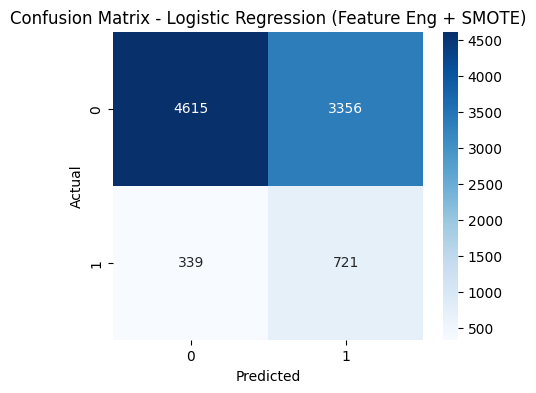

In [12]:
# Cell 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Feature Eng + SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
